In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from catboost import CatBoostRegressor
import shap



In [ ]:

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")


In [ ]:

# ==========================================
# 1. CHARGEMENT DES DONNÉES
# ==========================================
print("--- Chargement des données ---")
# Assurez-vous que le chemin est correct
df = pd.read_csv('../data/Loan_data.csv')

# Traitement des dates (déjà présent dans votre code)
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])
df['ApplicationYear'] = df['ApplicationDate'].dt.year
df['ApplicationMonth'] = df['ApplicationDate'].dt.month
df['ApplicationDay'] = df['ApplicationDate'].dt.day
df = df.drop(columns=['ApplicationDate'])


--- Chargement des données ---


--- Génération des graphes exploratoires ---


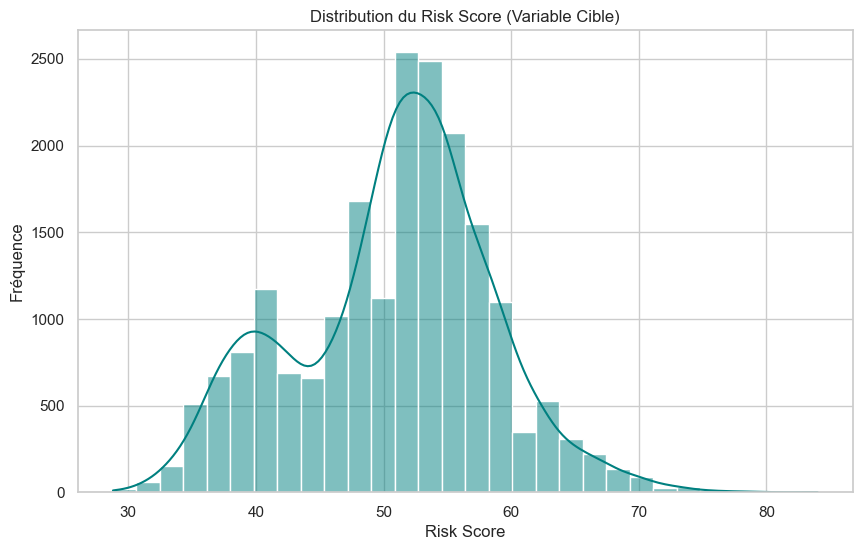

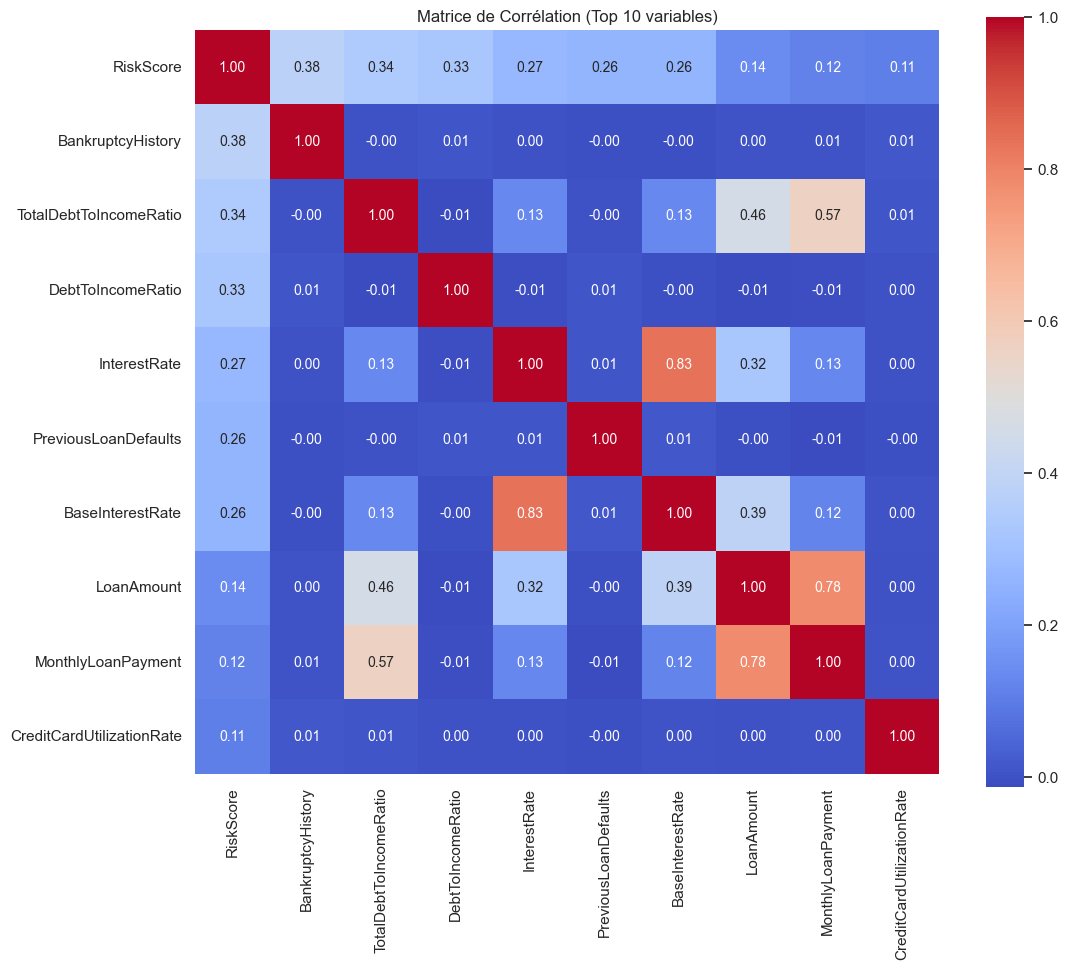

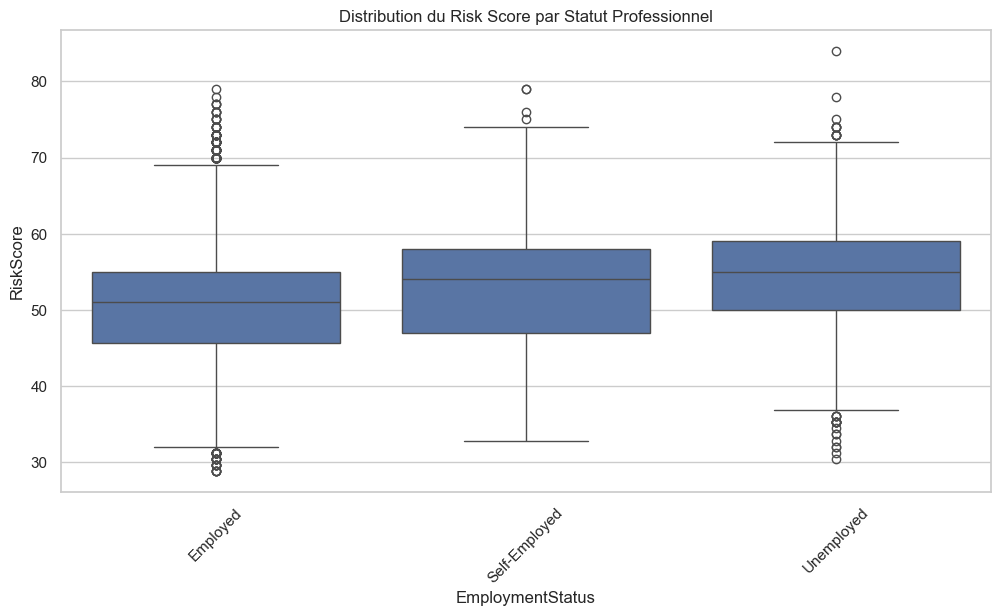

In [ ]:

# ==========================================
# 2. ANALYSE EXPLORATOIRE (EDA) & GRAPHES
# ==========================================
print("--- Génération des graphes exploratoires ---")

# Graphe 1 : Distribution de la variable cible (RiskScore)
plt.figure(figsize=(10, 6))
sns.histplot(df['RiskScore'], kde=True, bins=30, color='teal')
plt.title('Distribution du Risk Score (Variable Cible)')
plt.xlabel('Risk Score')
plt.ylabel('Fréquence')
plt.show()

# Graphe 2 : Matrice de corrélation (Top 10 variables corrélées)
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
# On se concentre sur les corrélations avec le RiskScore
cols = corr.nlargest(10, 'RiskScore')['RiskScore'].index
cm = np.corrcoef(df[cols].values.T)
sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', 
            annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values, cmap='coolwarm')
plt.title('Matrice de Corrélation (Top 10 variables)')
plt.show()

# Graphe 3 : Relation Catégorielle (Ex: Emploi vs RiskScore)
plt.figure(figsize=(12, 6))
sns.boxplot(x='EmploymentStatus', y='RiskScore', data=df)
plt.xticks(rotation=45)
plt.title('Distribution du Risk Score par Statut Professionnel')
plt.show()


In [ ]:

# ==========================================
# 3. FEATURE ENGINEERING (AMÉLIORATIONS)
# ==========================================
print("--- Feature Engineering ---")

# A. Transformations Logarithmiques pour réduire l'asymétrie (Skewness)
# On utilise log1p (log(1+x)) pour gérer les valeurs nulles
cols_to_log = ['AnnualIncome', 'LoanAmount', 'NetWorth', 'TotalAssets', 'TotalLiabilities']
for col in cols_to_log:
    # On vérifie qu'il n'y a pas de valeurs négatives problématiques
    if (df[col] >= 0).all():
        df[f'Log_{col}'] = np.log1p(df[col])

# B. Création de ratios financiers
# Charge mensuelle relative au revenu (vérification de la cohérence avec DebtToIncomeRatio)
df['Calculated_DTI'] = df['MonthlyLoanPayment'] / (df['MonthlyIncome'] + 1) # +1 pour éviter division par 0

# C. Binning de l'âge (Tranches d'âge)
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)


--- Feature Engineering ---


In [ ]:

# ==========================================
# 4. PRÉPARATION (ENCODING & SPLIT)
# ==========================================
print("--- Préparation des données (Encoding & Split) ---")

# Séparation X / y
X = df.drop(columns=['RiskScore','LoanApproved'])
y = df['RiskScore']

# Identification des colonnes catégorielles et numériques
cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(include=['number']).columns

# One-Hot Encoding (pandas get_dummies est souvent plus simple pour la visualisation ensuite)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Split Train / Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Standardisation (Recommandé pour la Régression Linéaire, moins critique pour les arbres mais bon pour l'interprétabilité)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# On remet en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)


--- Préparation des données (Encoding & Split) ---


In [ ]:

# ==========================================
# 5. MODÉLISATION 1 : BASELINE (Régression Linéaire)
# ==========================================
print("\n--- Modèle 1 : Baseline (Régression Linéaire) ---")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Baseline - RMSE: {rmse_lr:.4f}")
print(f"Baseline - R²: {r2_lr:.4f}")



--- Modèle 1 : Baseline (Régression Linéaire) ---
Baseline - RMSE: 1.7831
Baseline - R²: 0.9488


In [ ]:

# ==========================================
# 6. MODÉLISATION 2 : CATBOOST (Votre modèle principal)
# ==========================================
print("\n--- Modèle 2 : CatBoost Regressor ---")

# Définition du modèle
cb_model = CatBoostRegressor(
    loss_function='RMSE',
    verbose=0, # On désactive le log verbeux pour la clarté
    thread_count=-1,
    early_stopping_rounds=50,
    random_state=42
)

# Grille d'hyperparamètres (Simplifiée pour l'exemple, à élargir si vous avez du temps de calcul)
param_grid = {
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'iterations': [500],
    'l2_leaf_reg': [1, 3]
}

TRAIN_CAT_BOOST = True # Mettre à True pour lancer le GridSearch

if TRAIN_CAT_BOOST:
    print("Démarrage du GridSearch pour CatBoost...")
    grid_search = GridSearchCV(
        estimator=cb_model,
        param_grid=param_grid,
        scoring='neg_root_mean_squared_error',
        cv=3,
        n_jobs=1
    )
    grid_search.fit(X_train, y_train) # CatBoost gère bien les données non scalées
    best_cb_model = grid_search.best_estimator_
    print(f"Meilleurs paramètres : {grid_search.best_params_}")
else:
    # Fallback si on ne veut pas réentraîner le GridSearch
    best_cb_model = CatBoostRegressor(depth=6, learning_rate=0.1, iterations=500, verbose=0)
    best_cb_model.fit(X_train, y_train)

# Prédictions
y_pred_cb = best_cb_model.predict(X_test)

rmse_cb = np.sqrt(mean_squared_error(y_test, y_pred_cb))
r2_cb = r2_score(y_test, y_pred_cb)
mae_cb = mean_absolute_error(y_test, y_pred_cb)

print(f"CatBoost - RMSE: {rmse_cb:.4f}")
print(f"CatBoost - MAE: {mae_cb:.4f}")
print(f"CatBoost - R²: {r2_cb:.4f}")



--- Modèle 2 : CatBoost Regressor ---
Démarrage du GridSearch pour CatBoost...
Meilleurs paramètres : {'depth': 4, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
CatBoost - RMSE: 0.1844
CatBoost - MAE: 0.0979
CatBoost - R²: 0.9995


In [ ]:

# ==========================================
# 7. MODÉLISATION 3 : RANDOM FOREST (Comparaison)
# ==========================================
print("\n--- Modèle 3 : Random Forest (Comparaison) ---")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Random Forest - RMSE: {rmse_rf:.4f}")



--- Modèle 3 : Random Forest (Comparaison) ---
Random Forest - RMSE: 1.4516



--- Analyse des résultats ---
                Modèle      RMSE
0    Baseline (Linear)  1.783134
1  CatBoost (Optimisé)  0.184408
2        Random Forest  1.451562


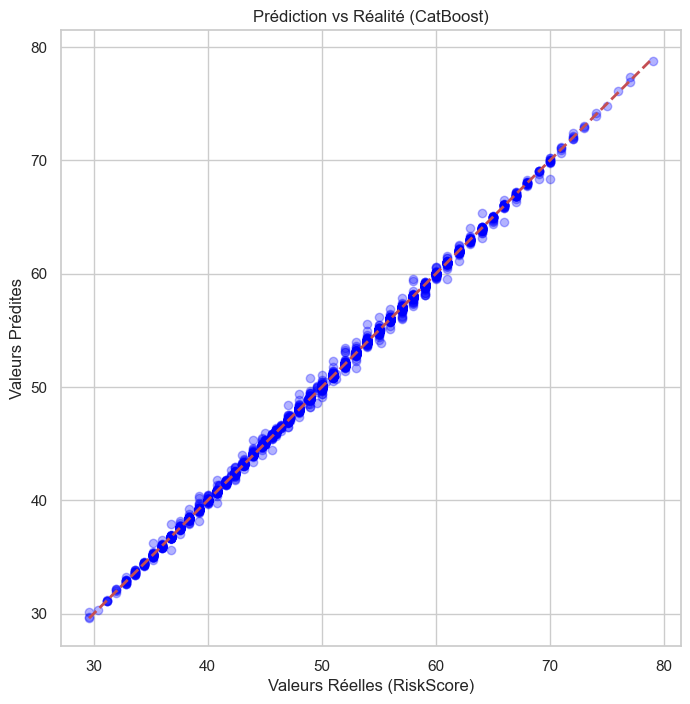

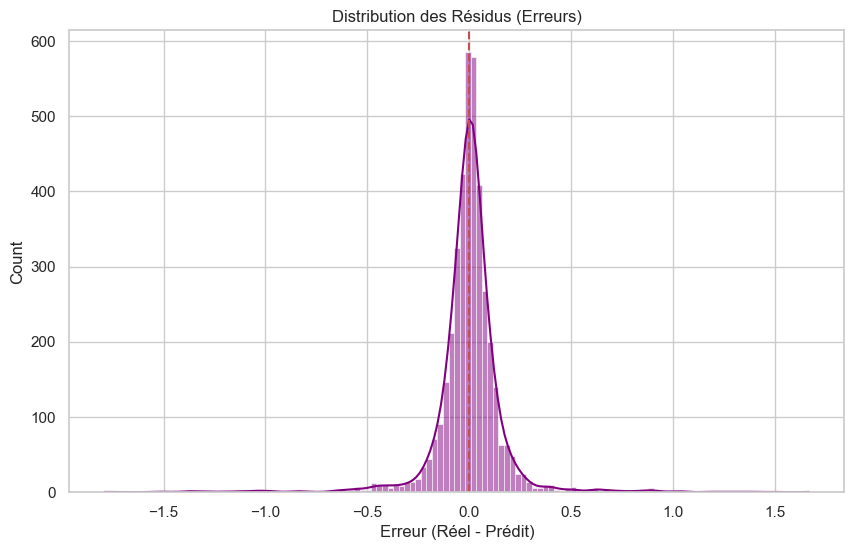

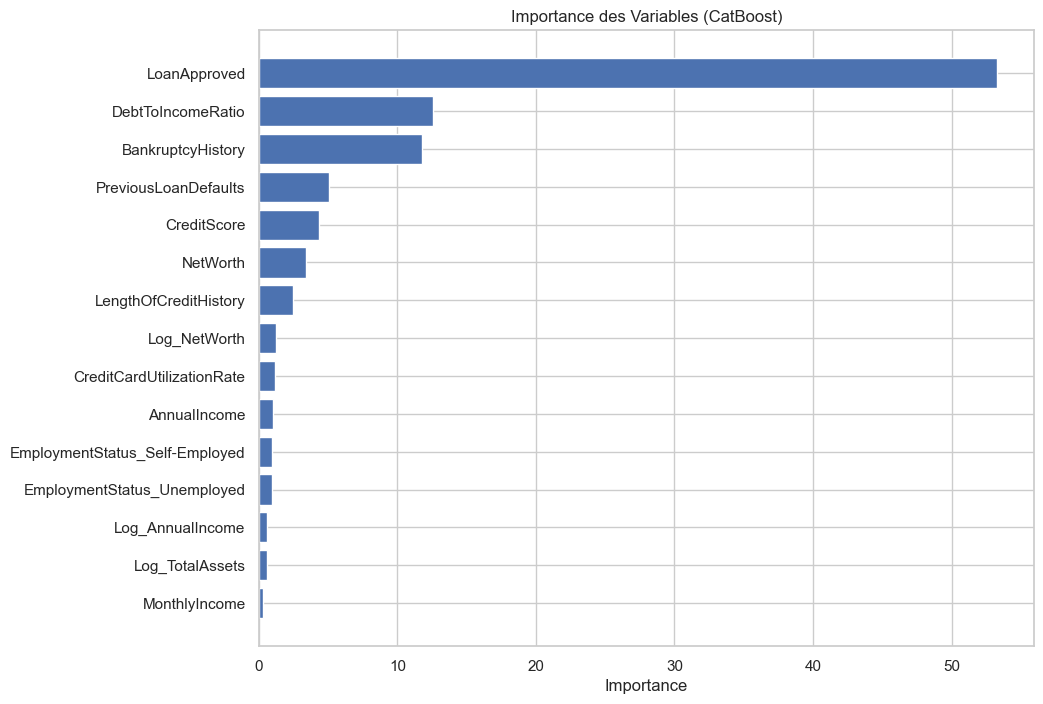

Génération du graphe SHAP...


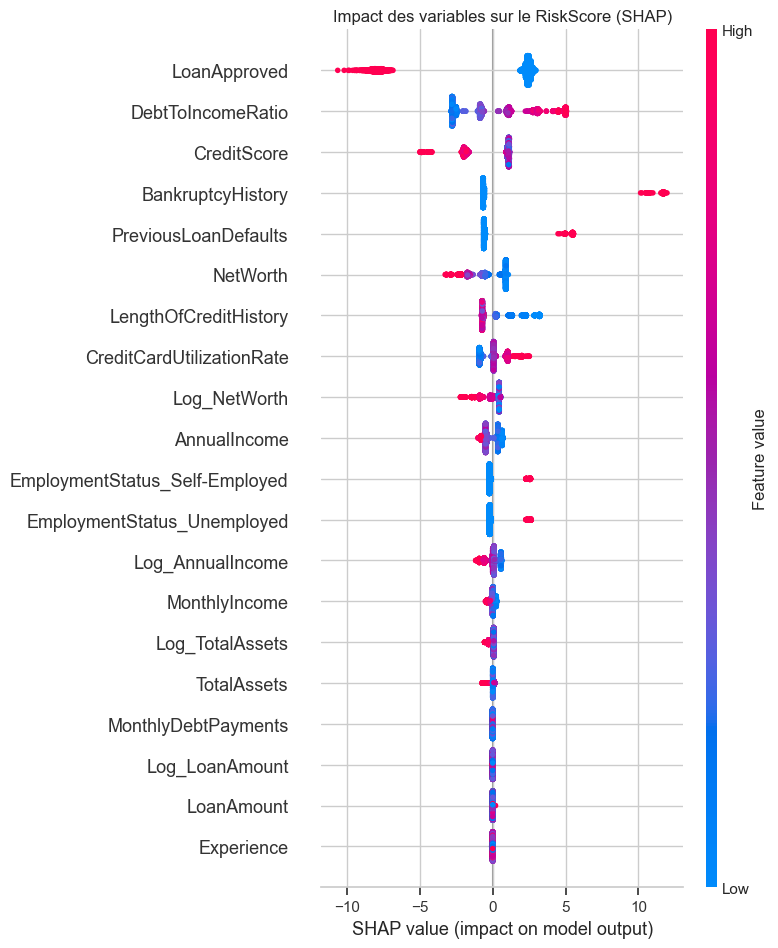

In [ ]:

# ==========================================
# 8. ANALYSE DES RÉSULTATS & GRAPHES DE PERFORMANCE
# ==========================================
print("\n--- Analyse des résultats ---")

# Tableau récapitulatif
results_df = pd.DataFrame({
    'Modèle': ['Baseline (Linear)', 'CatBoost (Optimisé)', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_cb, rmse_rf]
})
print(results_df)

# Graphe 4 : Comparaison Prédictions vs Réalité (Pour CatBoost)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_cb, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs Réelles (RiskScore)')
plt.ylabel('Valeurs Prédites')
plt.title('Prédiction vs Réalité (CatBoost)')
plt.show()

# Graphe 5 : Analyse des Résidus
residuals = y_test - y_pred_cb
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution des Résidus (Erreurs)')
plt.xlabel('Erreur (Réel - Prédit)')
plt.axvline(x=0, color='r', linestyle='--')
plt.show()

# Graphe 6 : Feature Importance (CatBoost)
feature_importance = best_cb_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[-15:] # Top 15 variables

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.title('Importance des Variables (CatBoost)')
plt.xlabel('Importance')
plt.show()

# Graphe 7 : SHAP Values (Bonus Interprétabilité)
# Cela explique l'impact de chaque variable sur la prédiction (positif ou négatif)

print("Génération du graphe SHAP...")
explainer = shap.TreeExplainer(best_cb_model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Impact des variables sur le RiskScore (SHAP)")
plt.show()
